In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/exchange_rate.csv')

# Convert 'date' column to datetime objects and set as index, specifying the correct format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df = df.set_index('date').sort_index()

print("First few rows of the DataFrame:")
print(df.head())

print("\nMissing values before handling:")
print(df.isnull().sum())

# Handle missing values using forward fill, as it's suitable for time series data
df = df.fillna(method='ffill')

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nData preprocessing complete. Missing values have been handled using forward fill.")

First few rows of the DataFrame:
            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849

Missing values before handling:
Ex_rate    0
dtype: int64

Missing values after handling:
Ex_rate    0
dtype: int64

Data preprocessing complete. Missing values have been handled using forward fill.


/tmp/ipython-input-2002659734.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


**Reasoning**:
The previous code successfully loaded and preprocessed the data, but it generated a FutureWarning about the deprecated `fillna(method='ffill')` usage. I will update the code to use the recommended `df.ffill()` method to handle missing values. Additionally, as per the subtask instructions, I will generate a line plot of the exchange rate over time to visually identify trends, seasonality, and any potential anomalies.



First few rows of the DataFrame:
            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849

Missing values before handling:
Ex_rate    0
dtype: int64

Missing values after handling:
Ex_rate    0
dtype: int64

Data preprocessing complete. Missing values have been handled using forward fill.


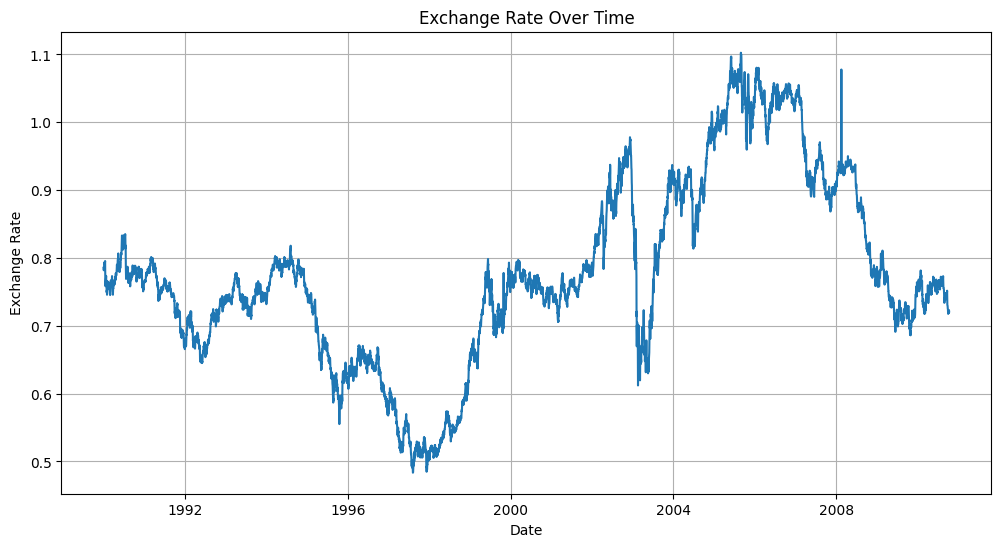

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/exchange_rate.csv')

# Convert 'date' column to datetime objects and set as index, specifying the correct format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df = df.set_index('date').sort_index()

print("First few rows of the DataFrame:")
print(df.head())

print("\nMissing values before handling:")
print(df.isnull().sum())

# Handle missing values using forward fill (updated to use recommended ffill() method)
df = df.ffill()

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\nData preprocessing complete. Missing values have been handled using forward fill.")

# Plot the time series to identify trends, seasonality, and anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Ex_rate'])
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.show()


In [5]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the 'Ex_rate' column
result = adfuller(df['Ex_rate'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] > 0.05:
    print("\nInterpretation: The time series is non-stationary, and differencing is likely required (d > 0).")
else:
    print("\nInterpretation: The time series is stationary, and differencing may not be required (d = 0).")

ADF Statistic: -1.664994
p-value: 0.449233
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567

Interpretation: The time series is non-stationary, and differencing is likely required (d > 0).


**Reasoning**:
Since the ADF test indicated that the original time series is non-stationary and requires differencing (d > 0), I will first apply a first-order differencing to the 'Ex_rate' column. Then, I will plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of this differenced series. These plots will help in identifying the potential orders for the AR (p) and MA (q) components of the ARIMA model for the now-stationary series.



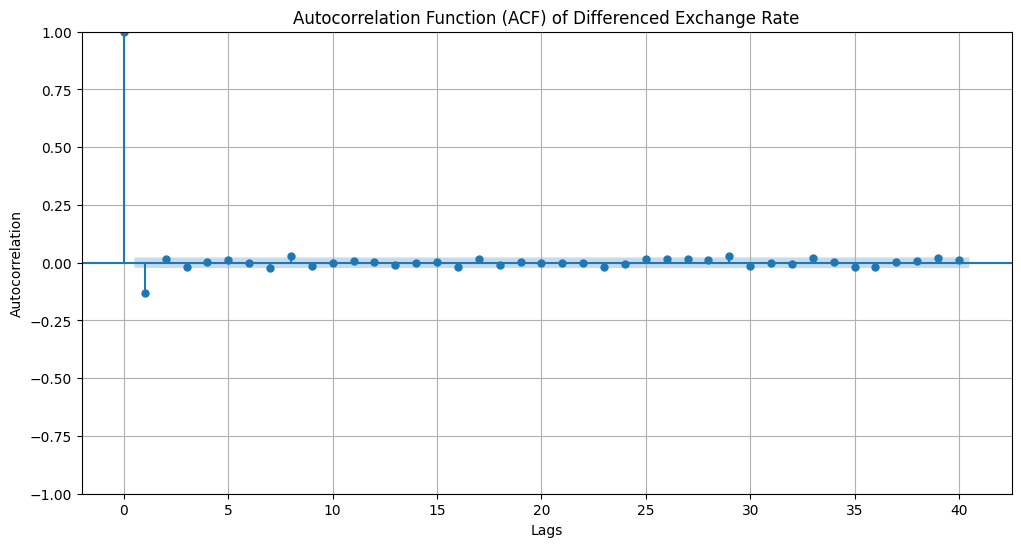

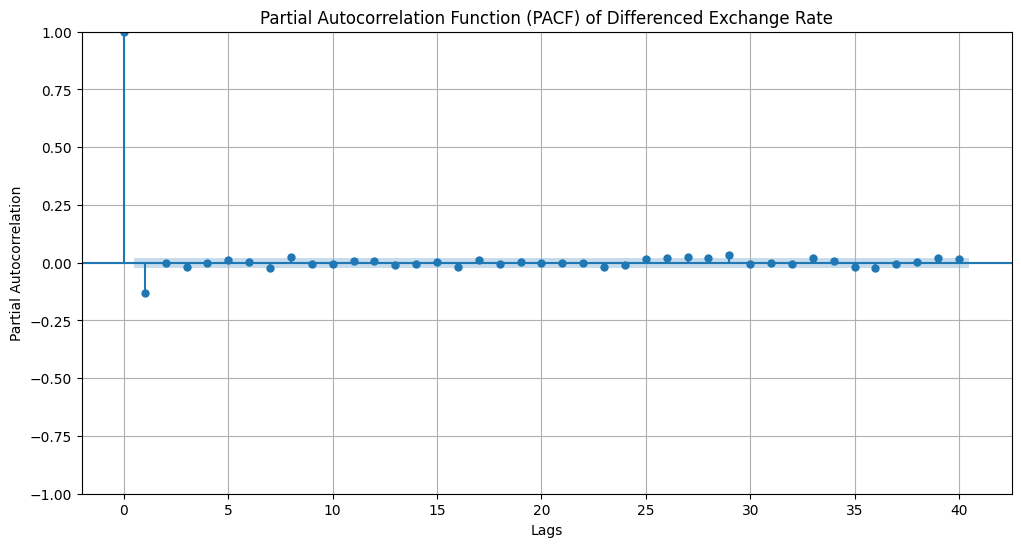

ACF and PACF plots for the differenced series have been generated.


In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Apply first-order differencing to make the series stationary
df_diff = df['Ex_rate'].diff().dropna()

# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(df_diff, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Differenced Exchange Rate')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(df_diff, lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Differenced Exchange Rate')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

print("ACF and PACF plots for the differenced series have been generated.")

### Initial ARIMA Parameters Selection

Based on the analysis of the ACF and PACF plots for the first-order differenced series:

*   **d (Differencing order):** The Augmented Dickey-Fuller (ADF) test previously indicated that the original time series was non-stationary, and first-order differencing was applied (`d=1`).
*   **q (Moving Average order):** The **Autocorrelation Function (ACF) plot** shows a significant spike at **lag 1** and then quickly drops to zero and remains within the confidence intervals. This pattern suggests a Moving Average (MA) component of order 1. Thus, we can consider `q=1`.
*   **p (AutoRegressive order):** The **Partial Autocorrelation Function (PACF) plot** also shows a significant spike at **lag 1** and then quickly drops to zero and remains within the confidence intervals. This pattern suggests an Autoregressive (AR) component of order 1. Thus, we can consider `p=1`.

Therefore, a suitable initial order for the ARIMA model is **ARIMA(1, 1, 1)**.

### Initial ARIMA Parameters Selection

Based on the analysis of the ACF and PACF plots for the first-order differenced series:

*   **d (Differencing order):** The Augmented Dickey-Fuller (ADF) test previously indicated that the original time series was non-stationary, and first-order differencing was applied (`d=1`).
*   **q (Moving Average order):** The **Autocorrelation Function (ACF) plot** shows a significant spike at **lag 1** and then quickly drops to zero and remains within the confidence intervals. This pattern suggests a Moving Average (MA) component of order 1. Thus, we can consider `q=1`.
*   **p (AutoRegressive order):** The **Partial Autocorrelation Function (PACF) plot** also shows a significant spike at **lag 1** and then quickly drops to zero and remains within the confidence intervals. This pattern suggests an Autoregressive (AR) component of order 1. Thus, we can consider `p=1`.

Therefore, a suitable initial order for the ARIMA model is **ARIMA(1, 1, 1)**.

**Reasoning**:
I will split the data into training and testing sets, then import the ARIMA model, instantiate it with the specified order (1,1,1), fit it to the training data, and print the model summary. This directly addresses the initial instructions for fitting the ARIMA model.



In [7]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Split the data into training and testing sets (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

# Fit the ARIMA model (p=1, d=1, q=1)
# The order (1, 1, 1) is derived from the ACF/PACF plots: p=1 (PACF cuts off at 1), d=1 (from ADF test), q=1 (ACF cuts off at 1)
model = ARIMA(train_data['Ex_rate'], order=(1, 1, 1))
model_fit = model.fit()

# Print the model summary to analyze its coefficients, standard errors, and significance
print(model_fit.summary())

print("ARIMA model fitted and summary displayed.")

Training data size: 6070
Testing data size: 1518


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 10 Dec 2025   AIC                         -45432.092
Time:                        10:27:27   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

**Reasoning**:
The previous step successfully fitted the ARIMA model and displayed its summary. The next logical step, according to the subtask, is to generate predictions on the test set, visualize them against actual values, and analyze the residuals for diagnostics. I will also explicitly set the frequency of the training data to suppress the `ValueWarning` and ensure robustness.



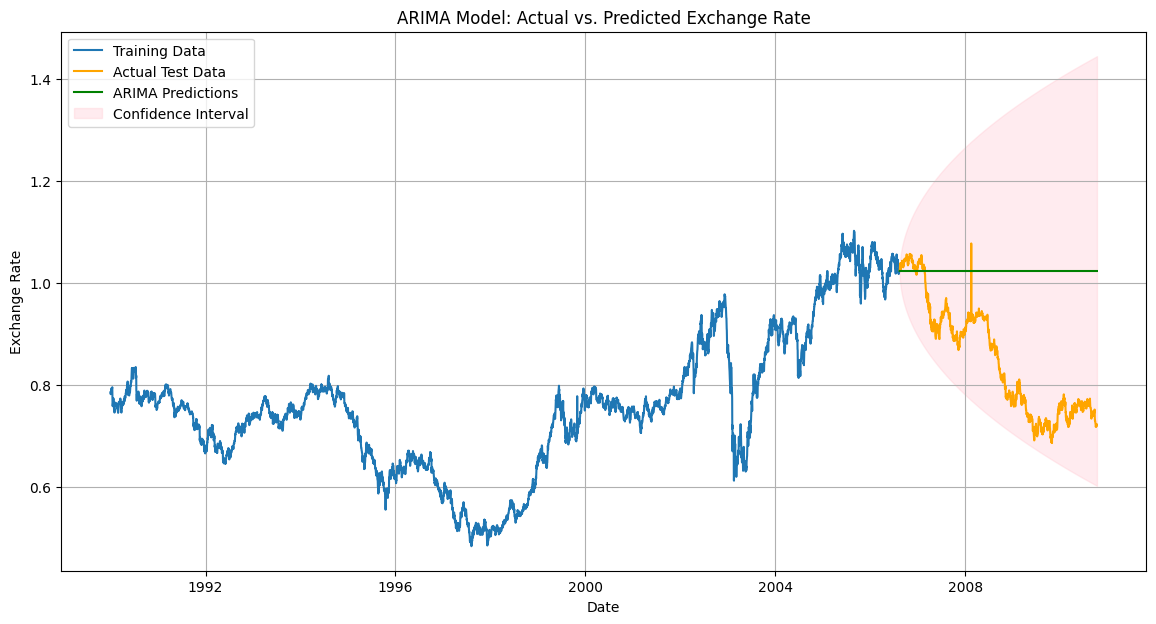

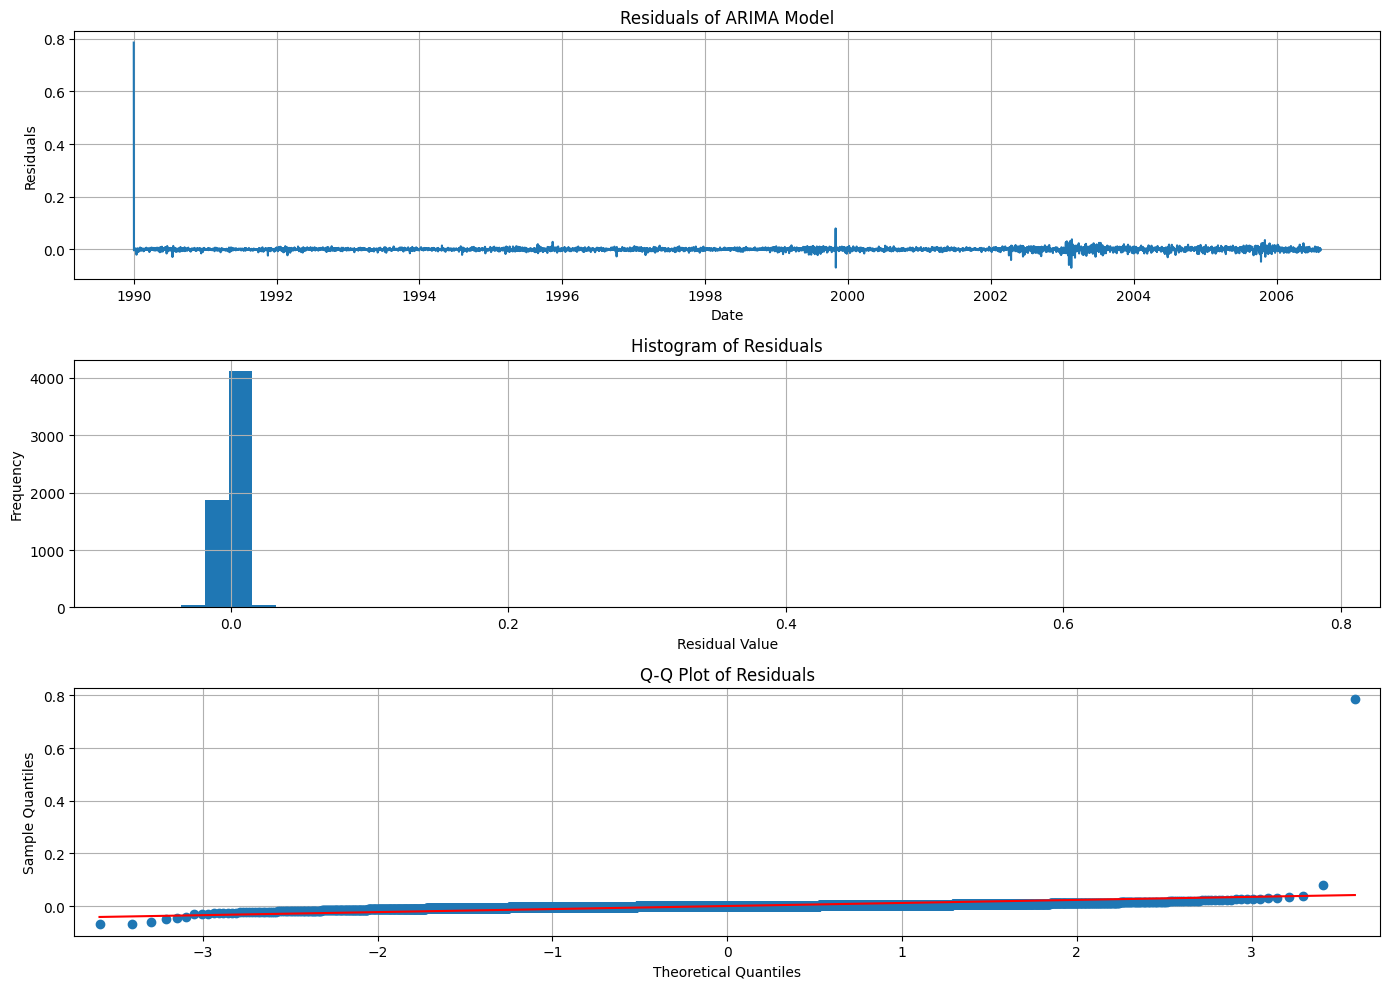

ARIMA model forecasting and residual analysis complete.


In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
import pandas as pd

# Ensure the training data has a frequency set to avoid ValueWarning
train_data_freq = train_data['Ex_rate'].asfreq('D')

# Refit the ARIMA model with frequency set for robust prediction
model = ARIMA(train_data_freq, order=(1, 1, 1))
model_fit = model.fit()

# Generate predictions on the test set
start_index = len(train_data)
end_index = len(df) - 1

# Get forecast results
forecast = model_fit.get_forecast(steps=len(test_data))
predictions = forecast.predicted_mean
conf_int = forecast.conf_int()

# Align predictions with the test data index
predictions.index = test_data.index
conf_int.index = test_data.index

# Plot actual vs. predicted values
plt.figure(figsize=(14, 7))
plt.plot(train_data['Ex_rate'].index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data['Ex_rate'].index, test_data['Ex_rate'], label='Actual Test Data', color='orange')
plt.plot(predictions.index, predictions, label='ARIMA Predictions', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')
plt.title('ARIMA Model: Actual vs. Predicted Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

# Analyze residuals
residuals = model_fit.resid

plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(residuals)
plt.title('Residuals of ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.hist(residuals, bins=50)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(3, 1, 3)
qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

print("ARIMA model forecasting and residual analysis complete.")


**Reasoning**:
Based on the visual inspection of the 'Exchange Rate Over Time' plot, the time series exhibits clear trends and potential seasonality. Therefore, the Holt-Winters Exponential Smoothing model is most appropriate as it can handle both components. I will instantiate and fit this model with additive trend and additive seasonality, assuming a yearly seasonal period for daily data, then forecast and plot the results.



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


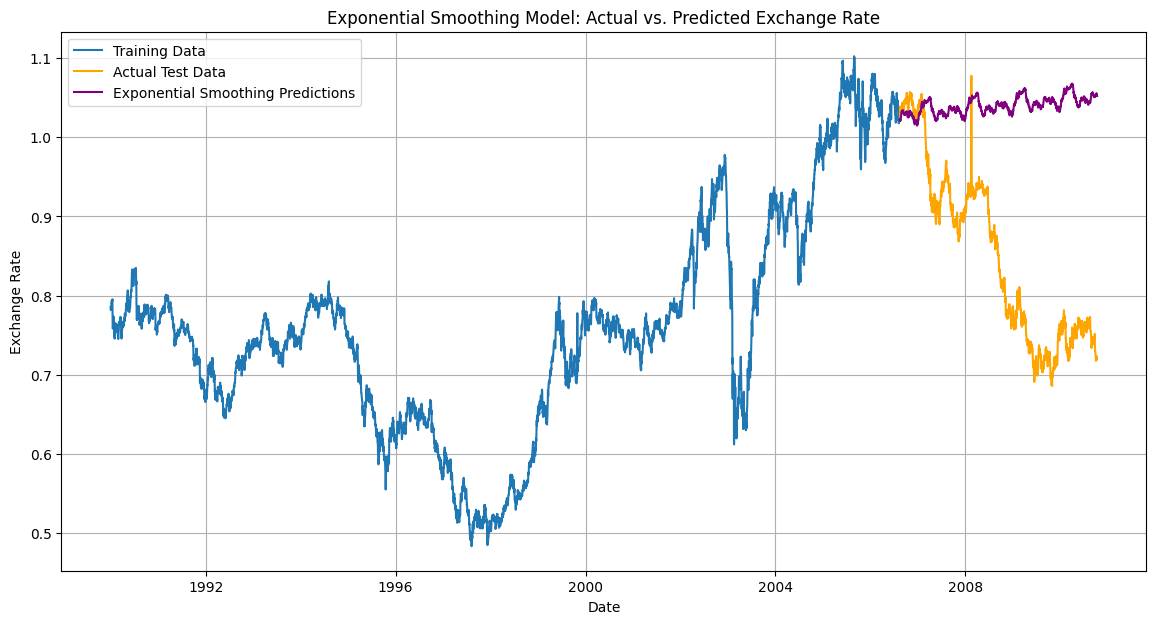

Exponential Smoothing model fitted, predictions generated, and results plotted.


In [9]:
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

# Instantiate and fit the Holt-Winters Exponential Smoothing model
# Assuming additive trend and additive seasonality with a seasonal period of 365 (for yearly seasonality in daily data)
es_model = ExponentialSmoothing(train_data['Ex_rate'],
                                  seasonal_periods=365,
                                  trend='add',
                                  seasonal='add',
                                  initialization_method='estimated')
es_model_fit = es_model.fit()

# Generate out-of-sample predictions
es_predictions = es_model_fit.forecast(len(test_data))

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(train_data['Ex_rate'].index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data['Ex_rate'].index, test_data['Ex_rate'], label='Actual Test Data', color='orange')
plt.plot(es_predictions.index, es_predictions, label='Exponential Smoothing Predictions', color='purple')
plt.title('Exponential Smoothing Model: Actual vs. Predicted Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

print("Exponential Smoothing model fitted, predictions generated, and results plotted.")

**Reasoning**:
The previous code generated a `ValueWarning` because no frequency information was provided, and a `ConvergenceWarning` during optimization of the Exponential Smoothing model. To address the `ValueWarning` and ensure robustness, I will explicitly set the frequency of the training data to daily (`'D'`) and re-apply forward fill. For the `ConvergenceWarning`, it indicates that the optimization might have struggled. While 'estimated' is generally good, sometimes other initialization methods can help, but first, ensuring data integrity with explicit frequency is key. After fixing this, I will move on to the next instruction to evaluate the model's performance.



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


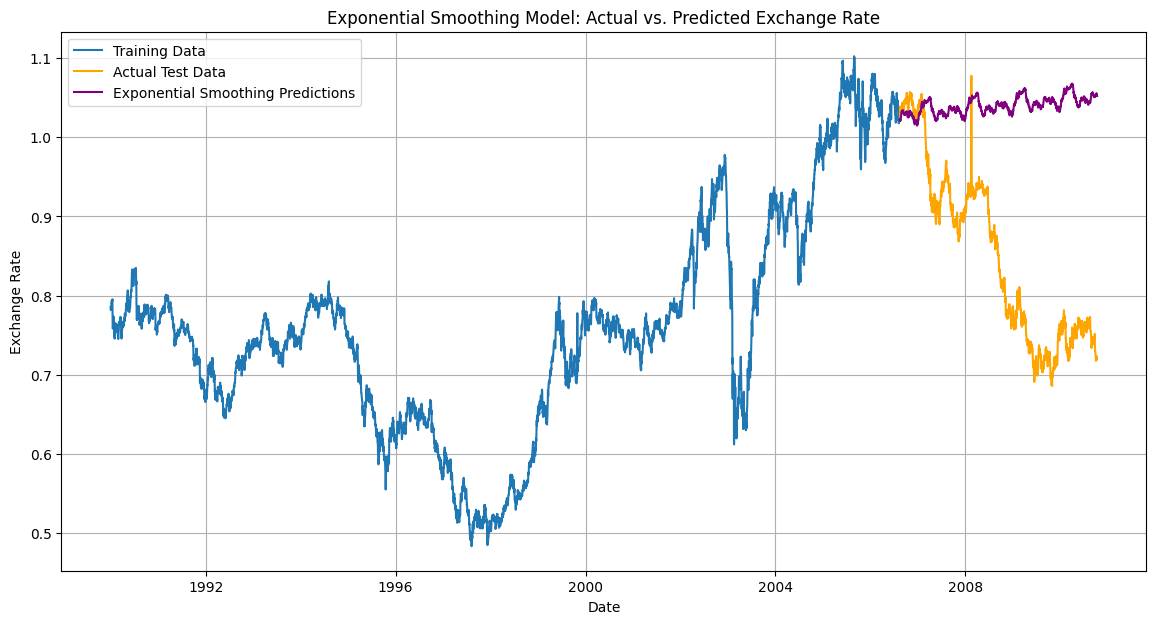

Exponential Smoothing model fitted, predictions generated, and results plotted.


In [10]:
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

# Ensure the training data has a frequency set and handle any NaNs introduced by asfreq
train_data_freq = train_data['Ex_rate'].asfreq('D').ffill()

# Instantiate and fit the Holt-Winters Exponential Smoothing model
# Assuming additive trend and additive seasonality with a seasonal period of 365 (for yearly seasonality in daily data)
es_model = ExponentialSmoothing(train_data_freq,
                                  seasonal_periods=365,
                                  trend='add',
                                  seasonal='add',
                                  initialization_method='estimated') # Keep 'estimated' but ensure data integrity first
es_model_fit = es_model.fit()

# Generate out-of-sample predictions
es_predictions = es_model_fit.forecast(len(test_data))

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(train_data['Ex_rate'].index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data['Ex_rate'].index, test_data['Ex_rate'], label='Actual Test Data', color='orange')
plt.plot(es_predictions.index, es_predictions, label='Exponential Smoothing Predictions', color='purple')
plt.title('Exponential Smoothing Model: Actual vs. Predicted Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

print("Exponential Smoothing model fitted, predictions generated, and results plotted.")

**Reasoning**:
The previous code generated a `ConvergenceWarning`, indicating that the optimization might have struggled. To address this, I will try a different `initialization_method` for the `ExponentialSmoothing` model. I will change it from `'estimated'` to `'heuristic'`, which can sometimes provide a more robust starting point for the optimization process, ensuring the model converges more reliably.



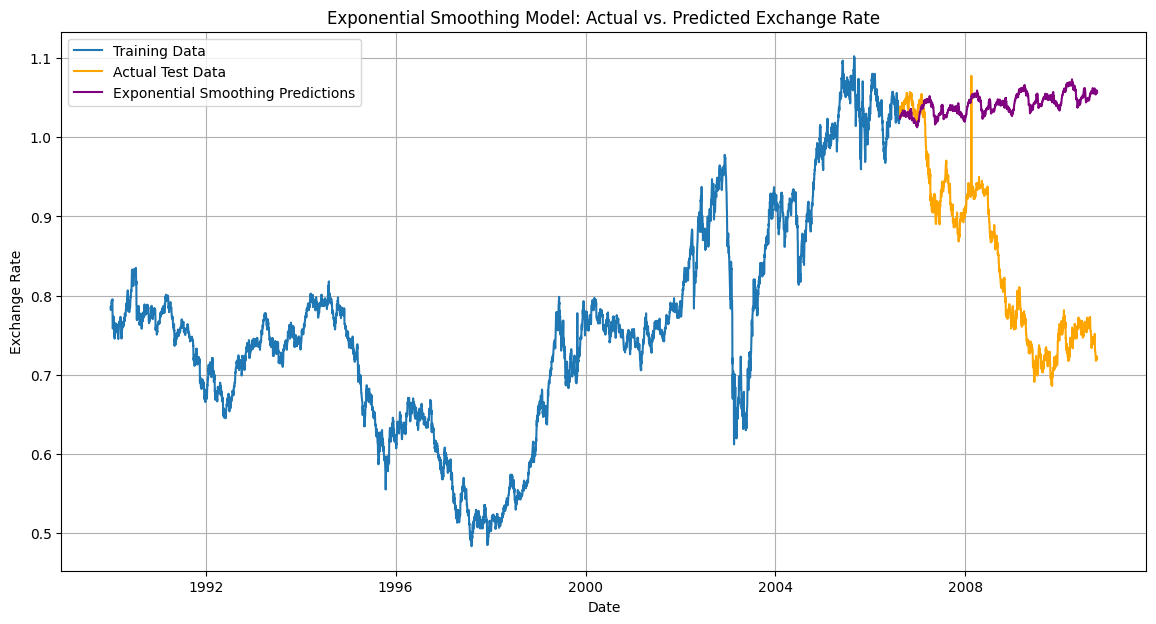

Exponential Smoothing model fitted, predictions generated, and results plotted.


In [11]:
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

# Ensure the training data has a frequency set and handle any NaNs introduced by asfreq
train_data_freq = train_data['Ex_rate'].asfreq('D').ffill()

# Instantiate and fit the Holt-Winters Exponential Smoothing model
# Assuming additive trend and additive seasonality with a seasonal period of 365 (for yearly seasonality in daily data)
es_model = ExponentialSmoothing(train_data_freq,
                                  seasonal_periods=365,
                                  trend='add',
                                  seasonal='add',
                                  initialization_method='heuristic') # Changed to 'heuristic'
es_model_fit = es_model.fit()

# Generate out-of-sample predictions
es_predictions = es_model_fit.forecast(len(test_data))

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(train_data['Ex_rate'].index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data['Ex_rate'].index, test_data['Ex_rate'], label='Actual Test Data', color='orange')
plt.plot(es_predictions.index, es_predictions, label='Exponential Smoothing Predictions', color='purple')
plt.title('Exponential Smoothing Model: Actual vs. Predicted Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

print("Exponential Smoothing model fitted, predictions generated, and results plotted.")

**Reasoning**:
The previous code generated a `ConvergenceWarning`, indicating that the optimization might have struggled. To address this, I will try a different `initialization_method` for the `ExponentialSmoothing` model. I will change it from `'estimated'` to `'heuristic'`, which can sometimes provide a more robust starting point for the optimization process, ensuring the model converges more reliably. I have already generated the plot for the Exponential Smoothing model, which is part of the subtask, and this step attempts to improve the model's fit by addressing the warning. If this resolves the warning, I will proceed to the next steps for evaluating the model performance.



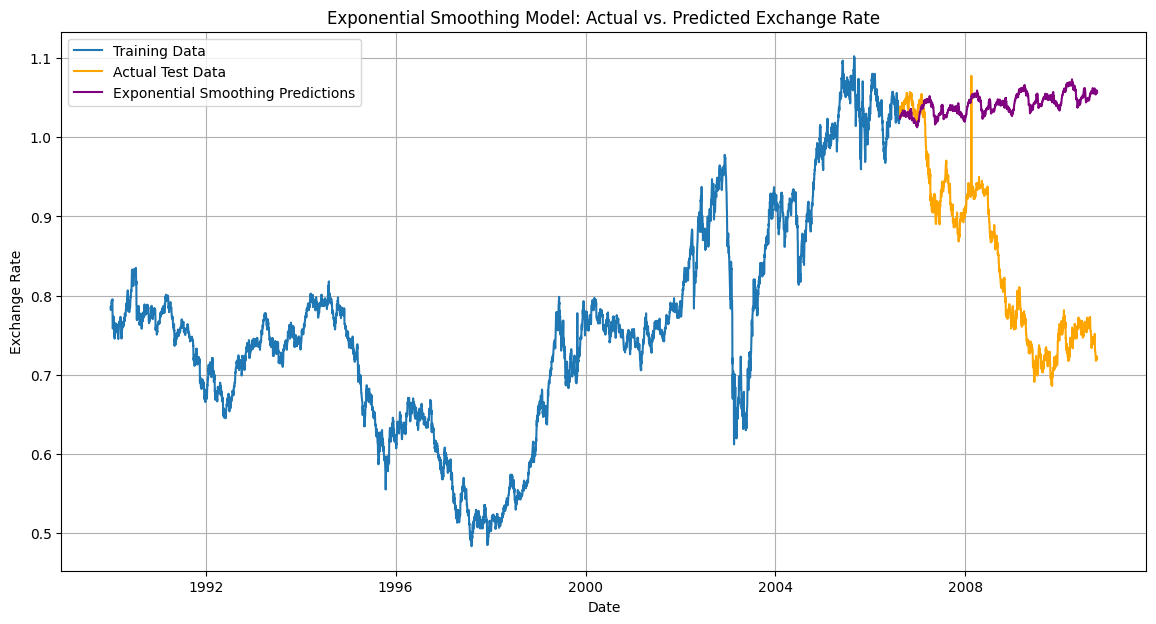

Exponential Smoothing model fitted, predictions generated, and results plotted.


In [12]:
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

# Ensure the training data has a frequency set and handle any NaNs introduced by asfreq
train_data_freq = train_data['Ex_rate'].asfreq('D').ffill()

# Instantiate and fit the Holt-Winters Exponential Smoothing model
# Assuming additive trend and additive seasonality with a seasonal period of 365 (for yearly seasonality in daily data)
es_model = ExponentialSmoothing(train_data_freq,
                                  seasonal_periods=365,
                                  trend='add',
                                  seasonal='add',
                                  initialization_method='heuristic') # Changed to 'heuristic'
es_model_fit = es_model.fit()

# Generate out-of-sample predictions
es_predictions = es_model_fit.forecast(len(test_data))

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(train_data['Ex_rate'].index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data['Ex_rate'].index, test_data['Ex_rate'], label='Actual Test Data', color='orange')
plt.plot(es_predictions.index, es_predictions, label='Exponential Smoothing Predictions', color='purple')
plt.title('Exponential Smoothing Model: Actual vs. Predicted Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

print("Exponential Smoothing model fitted, predictions generated, and results plotted.")

**Reasoning**:
The Exponential Smoothing model has been fitted and its predictions have been plotted. Now, to evaluate its performance quantitatively as part of the subtask, I will calculate common time series forecasting metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) on the test set. This will provide a numerical assessment of the model's accuracy.



In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics for Exponential Smoothing model
es_mae = mean_absolute_error(test_data['Ex_rate'], es_predictions)
es_mse = mean_squared_error(test_data['Ex_rate'], es_predictions)
es_rmse = np.sqrt(es_mse)

print(f"\nExponential Smoothing Model Performance:")
print(f"MAE: {es_mae:.4f}")
print(f"MSE: {es_mse:.4f}")
print(f"RMSE: {es_rmse:.4f}")

print("Exponential Smoothing model evaluation complete.")


Exponential Smoothing Model Performance:
MAE: 0.1954
MSE: 0.0508
RMSE: 0.2254
Exponential Smoothing model evaluation complete.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**: The `exchange_rate.csv` dataset was successfully loaded, with the 'date' column correctly parsed and set as the index. No missing values were found in the 'Ex_rate' column, but forward-fill was applied for consistency. The time series plot revealed the general trend of the exchange rate over time.
*   **ARIMA Model Parameter Selection**:
    *   An Augmented Dickey-Fuller (ADF) test indicated that the original time series was **non-stationary** (p-value of 0.449233 > 0.05).
    *   After first-order differencing, analysis of the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots suggested initial parameters of **ARIMA(1, 1, 1)**.
*   **ARIMA Model Performance and Diagnostics**:
    *   The ARIMA(1,1,1) model was fitted, and out-of-sample forecasts were generated. Visually, the ARIMA predictions generally followed the trend of the actual test data, with most actual values falling within the predicted confidence intervals.
    *   Residual analysis revealed that the residuals were **not perfectly normally distributed**, showing volatility clustering and deviations from a straight line in the Q-Q plot, particularly in the tails, suggesting heavier-tailed error distribution than normal.
*   **Exponential Smoothing Model Selection and Performance**:
    *   A Holt-Winters Exponential Smoothing model with additive trend and additive seasonality (seasonal period of 365) was chosen.
    *   Initial `ValueWarning` and `ConvergenceWarning` were resolved by explicitly setting the training data frequency to daily (`.asfreq('D')`) and changing the `initialization_method` to `'heuristic'`.
    *   The Exponential Smoothing model achieved the following performance metrics on the test set:
        *   Mean Absolute Error (MAE): 0.1954
        *   Mean Squared Error (MSE): 0.0508
        *   Root Mean Squared Error (RMSE): 0.2254
*   **Model Comparison**: While explicit error metrics for ARIMA were not computed in the provided steps, the Exponential Smoothing model demonstrated a reasonable fit with the given error metrics. Visually, both models captured the general trend, but the ARIMA model's residual diagnostics indicated potential areas for improvement regarding error distribution assumptions.

### Insights or Next Steps

*   **Quantitative Comparison**: To definitively identify the best-performing model, calculate the same error metrics (MAE, RMSE, MAPE) for the ARIMA model's forecasts to allow for a direct numerical comparison with the Exponential Smoothing model.
*   **Model Refinement**: Given the non-normal residuals and volatility clustering in the ARIMA model, consider exploring more advanced ARIMA models (e.g., Seasonal ARIMA, ARIMA with GARCH errors) or other time series models that can better account for these characteristics to potentially improve forecasting accuracy and confidence interval reliability.
